BEMORLARDA DIABET KASALLIGINI ANIQLASH UCHUN K-NN MODEL


In [ ]:
# Bizga kerakli kutubxonalrni chaqirib olamiz

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, accuracy_score


In [ ]:
# datasetni yuklash

URL =URL = 'https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/diabetes.csv'
df = pd.read_csv(URL)

  Data frame bn tanishuv

In [ ]:
# datasetni boshidan 5 qator namuna koramiz
df.head(5)

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,0,33.6,0.627,50,1
1,1,85,0,26.6,0.351,31,0
2,8,183,0,23.3,0.672,32,1
3,1,89,94,28.1,0.167,21,0
4,0,137,168,43.1,2.288,33,1


In [ ]:
# df 'olchamini ko'rib olamiz
df.shape

(768, 9)

In [ ]:
# df haqidagi infolarni olamiz
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
# datasetdagi nan qiymatlarni tekshirib olamiz

df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


  Dfni tahlil qilish


In [ ]:
# tahlih qilamiz
df.describe()

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# balansni tekshiramiz
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [ ]:
# outcome ustuni bn  boshqa ustunlarni bog'likligini tekshiramiz
col_matrix = df.corr().abs()
col_matrix.style.background_gradient(cmap='coolwarm')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,0.081672,0.073535,0.017683,0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,0.113970,0.074752
Insulin,0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,0.113970,0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [ ]:
# outcome ustuniga eng ko'p bog'liq ustunlarni topamiz
df.corrwith(df['Outcome']).abs().sort_values(ascending=False)

,0
Outcome,1.000000
Glucose,0.466581
BMI,0.292695
Age,0.238356
Pregnancies,0.221898
DiabetesPedigreeFunction,0.173844
Insulin,0.130548
SkinThickness,0.074752
BloodPressure,0.065068


In [ ]:
#shovqinli ustunlarni tashlab yuboramiz
df = df.drop(['BloodPressure','SkinThickness'], axis=1)

ML ga tayyorlash

In [ ]:
# ML ga tayyorlymiz
x = df.drop('Outcome',axis=1)
y = df['Outcome']

In [ ]:
# Train/test split qilamiz

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test =train_test_split(x,y, test_size=0.2,random_state =77)



In [ ]:
# ustunlardagi 0 qiymatlarni nan ga otkazib olamiz
cols = ['Glucose','Insulin','BMI']

x_train[cols] = x_train[cols].replace(0, np.nan)
x_test[cols] = x_test[cols].replace(0, np.nan)

In [ ]:
# imputer yordamida nan qiymatlarni median bn toldiramiz

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

x_train = pd.DataFrame(
    imputer.fit_transform(x_train),
    columns=x_train.columns
)

x_test = pd.DataFrame(
    imputer.transform(x_test),
    columns=x_test.columns
)

In [ ]:
# BALANCNI TO'G'IRLASH

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

In [ ]:
# malumotlarni standartscaler qilib olamiz

from sklearn.preprocessing import StandardScaler

scale = StandardScaler()
x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)

ML


In [ ]:
# K-NN model
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=7,weights='distance')
knn_model.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=7, weights='distance')

In [ ]:
# predict jarayoni
y_pred = knn_model.predict(x_test)

MODELNI BAHOLAYMIZ

  JACCARD INDEX

In [ ]:
# Jaccard indexi yordamida modelni baxolaymiz
from sklearn.metrics import jaccard_score
jaccard_score(y_test,y_pred)

np.float64(0.4235294117647059)

Confusion matrix

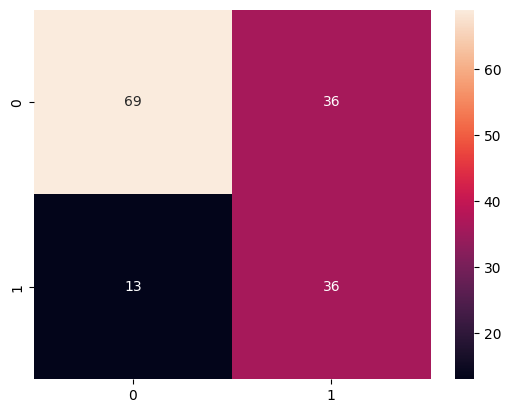

In [ ]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='g')
plt.show()

In [ ]:
# modelni baholaymiz
confusion_matrix(y_test,y_pred)

array([[69, 36],
       [13, 36]])

In [ ]:
# Model bashoratlarini haqiqiy qiymatlar bilan solishtirish

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Precision: model "diabet bor" degan holatlarning qanchasi to'g'ri
precision = precision_score(y_test, y_pred)

# Recall: haqiqiy diabetli bemorlarning qanchasi to'g'ri aniqlandi
recall = recall_score(y_test, y_pred)

# F1-score: Precision va Recall ning muvozanatli o'rtachasi
f1 = f1_score(y_test, y_pred)

# Accuracy: barcha bashoratlarning qanchasi to'g'r
accuracy = accuracy_score(y_test, y_pred)

# Natijalarni chiqarish
print(f"{precision=}\n{recall=}\n{f1=}\n{accuracy=}")

precision=0.5
recall=0.7346938775510204
f1=0.5950413223140496
accuracy=0.6818181818181818


In [ ]:
# Classification report - barcha metrikalarni bir joyda ko'rish
# Precision, Recall, F1-score va Support ni chiqaradi

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.66      0.74       105
           1       0.50      0.73      0.60        49

    accuracy                           0.68       154
   macro avg       0.67      0.70      0.67       154
weighted avg       0.73      0.68      0.69       154



Cross-validation yordamida tekshiramiz

In [ ]:
# Cross validation
from sklearn.model_selection import cross_val_predict
predict = cross_val_predict(estimator = knn_model, X = x, y = y, cv = 5)

# Modelni baholash
from sklearn.metrics import classification_report
print("Classification Report: \n",classification_report(y, predict))

Classification Report: 
               precision    recall  f1-score   support

           0       0.78      0.82      0.80       500
           1       0.63      0.56      0.59       268

    accuracy                           0.73       768
   macro avg       0.70      0.69      0.69       768
weighted avg       0.72      0.73      0.73       768



Eng yaxshi k ni topish

fop loop yordamida


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = []

for k in range(1, 25):
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, x_train, y_train, cv=5, scoring='f1')
    scores.append(score.mean())

best_k = np.argmax(scores) + 1

print("Best k:", best_k)

Best k: 7


Grid Search yordamida

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': np.arange(1, 25)}

knn_gscv = GridSearchCV(knn, param_grid, cv=5)

knn_gscv.fit(x, y)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(n_neighbors=24),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])})

In [ ]:
knn_gscv.cv_results_['rank_test_score']

array([24, 22, 23, 21, 18,  9,  1, 11,  6, 13,  5,  7,  2,  3, 16, 17, 10,
       19, 14, 20,  4, 12, 15,  8], dtype=int32)

In [ ]:
knn_gscv.best_score_

np.float64(0.7422544775485951)

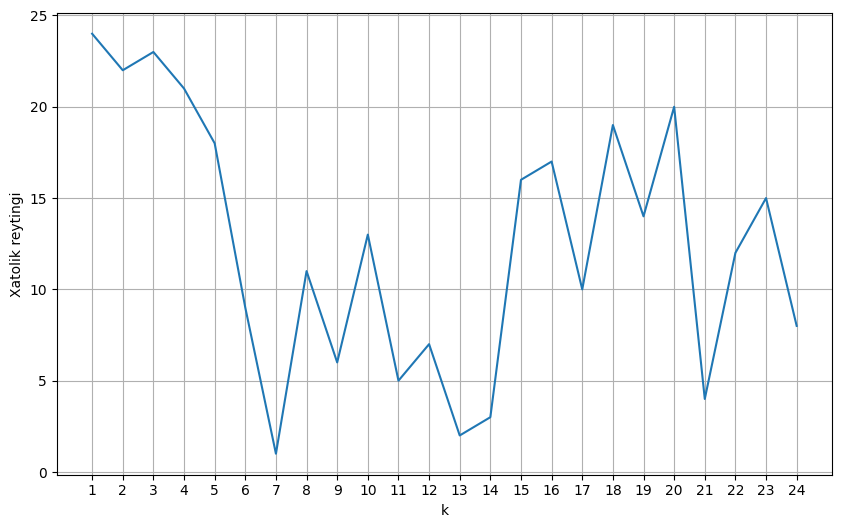

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(param_grid['n_neighbors'], knn_gscv.cv_results_['rank_test_score'])
plt.xticks(param_grid['n_neighbors'])
plt.xlabel("k")
plt.ylabel("Xatolik reytingi")
plt.grid()
plt.show()